In [1]:
import os
import json
import math
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)

C:\Users\jaymo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\jaymo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
OUTPUT_DIR = "realistic_rehab_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_PATIENTS = 10000
DAYS = 21

# Binary target:
# 0 = continue monitoring
# 1 = therapist review recommended
LABELS = {
    0: "continue_monitoring",
    1: "therapist_review_recommended"
}

# Simulated trajectory archetypes.
# These are hidden data-generating states, not model inputs.
TRAJECTORY_ARCHETYPES = [
    "on_track",
    "slow_but_improving",
    "true_plateau",
    "worsening",
    "inconsistent_logging",
    "pain_limited"
]

print("Output directory:", OUTPUT_DIR)

Output directory: realistic_rehab_outputs


In [3]:
# Patient and caregiver profile generation

def sample_patient_profile(patient_id):
    """
    Generate realistic patient/caregiver characteristics.
    These are hidden or partly known context.
    Some could be available in the app; others are just data-generating variables.
    """

    severity = np.random.choice(
        ["mild", "moderate", "severe"],
        p=[0.35, 0.45, 0.20]
    )

    caregiver_skill = np.random.choice(
        ["low", "medium", "high"],
        p=[0.35, 0.45, 0.20]
    )

    caregiver_burden = np.random.choice(
        ["low", "medium", "high"],
        p=[0.30, 0.45, 0.25]
    )

    archetype = np.random.choice(
        TRAJECTORY_ARCHETYPES,
        p=[0.36, 0.22, 0.18, 0.08, 0.08, 0.08]
    )

    age = int(np.clip(np.random.normal(68, 9), 45, 92))

    # Baseline functional score, 0-5.
    # Think of this as a simplified guided task:
    # 0 = cannot attempt
    # 5 = completes independently with good quality
    if severity == "mild":
        baseline_function = np.random.uniform(2.0, 3.3)
    elif severity == "moderate":
        baseline_function = np.random.uniform(1.0, 2.4)
    else:
        baseline_function = np.random.uniform(0.2, 1.4)

    # Baseline ROM-like score, 0-100.
    # This could be a guided app estimate, not necessarily true degrees.
    if severity == "mild":
        baseline_rom_score = np.random.uniform(35, 55)
    elif severity == "moderate":
        baseline_rom_score = np.random.uniform(20, 42)
    else:
        baseline_rom_score = np.random.uniform(5, 30)

    # Pain baseline.
    pain_base = {
        "mild": np.random.uniform(1.0, 3.0),
        "moderate": np.random.uniform(2.0, 5.0),
        "severe": np.random.uniform(3.5, 7.0),
    }[severity]

    # Therapist/protocol targets for week 3.
    # These are personalized-ish based on severity.
    # In a real product, they should come from the care plan.
    if severity == "mild":
        target_function_wk3 = np.random.uniform(4.0, 5.0)
        target_rom_wk3 = np.random.uniform(75, 95)
    elif severity == "moderate":
        target_function_wk3 = np.random.uniform(3.0, 4.3)
        target_rom_wk3 = np.random.uniform(60, 85)
    else:
        target_function_wk3 = np.random.uniform(2.0, 3.4)
        target_rom_wk3 = np.random.uniform(45, 70)

    # Caregiver measurement noise and bias.
    if caregiver_skill == "high":
        measurement_noise = np.random.uniform(2.0, 4.0)
        measurement_bias = np.random.normal(0, 2.0)
        rounding_increment = 1
    elif caregiver_skill == "medium":
        measurement_noise = np.random.uniform(4.0, 8.0)
        measurement_bias = np.random.normal(0, 4.0)
        rounding_increment = 5
    else:
        measurement_noise = np.random.uniform(7.0, 13.0)
        measurement_bias = np.random.normal(0, 7.0)
        rounding_increment = 10

    # Adherence tendency.
    # High burden lowers adherence.
    burden_penalty = {
        "low": 0.00,
        "medium": 0.08,
        "high": 0.18
    }[caregiver_burden]

    base_adherence_probability = np.clip(
        np.random.normal(0.88, 0.08) - burden_penalty,
        0.45,
        0.99
    )

    # Rural/offline logging irregularity.
    # This is not connectivity failure exactly; it represents missed daily entries.
    logging_reliability = np.clip(
        np.random.normal(0.92, 0.07) - burden_penalty / 2,
        0.55,
        0.99
    )

    return {
        "patient_id": patient_id,
        "age": age,
        "severity": severity,
        "caregiver_skill": caregiver_skill,
        "caregiver_burden": caregiver_burden,
        "archetype": archetype,

        "baseline_function": baseline_function,
        "baseline_rom_score": baseline_rom_score,
        "pain_base": pain_base,

        "target_function_wk3": target_function_wk3,
        "target_rom_wk3": target_rom_wk3,

        "measurement_noise": measurement_noise,
        "measurement_bias": measurement_bias,
        "rounding_increment": rounding_increment,

        "base_adherence_probability": base_adherence_probability,
        "logging_reliability": logging_reliability
    }

In [4]:
# Realistic daily simulation helpers

def clamp(x, low, high):
    return float(np.clip(x, low, high))

def round_to_increment(x, increment):
    if increment <= 1:
        return float(round(x, 1))
    return float(round(x / increment) * increment)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_true_recovery_curve(profile):
    """
    Simulate latent true function and true ROM-like score over 21 days.
    These are not perfectly observed by the caregiver.
    """

    days = np.arange(DAYS)

    baseline_function = profile["baseline_function"]
    baseline_rom = profile["baseline_rom_score"]

    target_function = profile["target_function_wk3"]
    target_rom = profile["target_rom_wk3"]

    archetype = profile["archetype"]

    # Expected total improvement if on track.
    function_gain_needed = target_function - baseline_function
    rom_gain_needed = target_rom - baseline_rom

    # Severity can change speed.
    severity_speed = {
        "mild": np.random.uniform(0.85, 1.25),
        "moderate": np.random.uniform(0.70, 1.10),
        "severe": np.random.uniform(0.45, 0.95)
    }[profile["severity"]]

    # Archetype effect on recovery.
    if archetype == "on_track":
        recovery_multiplier = np.random.uniform(0.95, 1.20)
        curve_shape = "nonlinear_improve"
    elif archetype == "slow_but_improving":
        recovery_multiplier = np.random.uniform(0.55, 0.80)
        curve_shape = "slow_linear"
    elif archetype == "true_plateau":
        recovery_multiplier = np.random.uniform(0.45, 0.75)
        curve_shape = "plateau"
    elif archetype == "worsening":
        recovery_multiplier = np.random.uniform(0.25, 0.55)
        curve_shape = "worsen_after_gain"
    elif archetype == "inconsistent_logging":
        recovery_multiplier = np.random.uniform(0.70, 1.05)
        curve_shape = "noisy_improve"
    elif archetype == "pain_limited":
        recovery_multiplier = np.random.uniform(0.45, 0.80)
        curve_shape = "pain_limited"
    else:
        recovery_multiplier = 0.8
        curve_shape = "slow_linear"

    effective_multiplier = recovery_multiplier * severity_speed

    # Latent improvement path in [0, 1-ish]
    if curve_shape == "nonlinear_improve":
        # Faster early gains, tapering later.
        progress = 1 - np.exp(-days / np.random.uniform(7, 11))
        progress = progress / progress[-1]

    elif curve_shape == "slow_linear":
        progress = np.linspace(0, 1, DAYS) ** np.random.uniform(1.0, 1.4)

    elif curve_shape == "plateau":
        plateau_day = np.random.randint(9, 14)
        early = np.linspace(0, np.random.uniform(0.45, 0.70), plateau_day)
        late = np.ones(DAYS - plateau_day) * early[-1]
        progress = np.concatenate([early, late])

    elif curve_shape == "worsen_after_gain":
        peak_day = np.random.randint(7, 13)
        early = np.linspace(0, np.random.uniform(0.45, 0.80), peak_day)
        late_end = np.random.uniform(0.20, 0.45)
        late = np.linspace(early[-1], late_end, DAYS - peak_day)
        progress = np.concatenate([early, late])

    elif curve_shape == "noisy_improve":
        progress = np.linspace(0, 1, DAYS)
        progress += np.random.normal(0, 0.06, DAYS)
        progress = np.maximum.accumulate(np.clip(progress, 0, 1))

    elif curve_shape == "pain_limited":
        # Some improvement but interrupted by pain flares.
        progress = np.linspace(0, 1, DAYS) ** np.random.uniform(1.2, 1.8)
        flare_start = np.random.randint(7, 15)
        flare_len = np.random.randint(3, 7)
        progress[flare_start:flare_start + flare_len] -= np.random.uniform(0.08, 0.18)
        progress = np.clip(progress, 0, 1)

    else:
        progress = np.linspace(0, 1, DAYS)

    true_function = baseline_function + function_gain_needed * effective_multiplier * progress
    true_rom = baseline_rom + rom_gain_needed * effective_multiplier * progress

    # Add small biological day-to-day variability.
    true_function += np.random.normal(0, 0.08, DAYS)
    true_rom += np.random.normal(0, 1.5, DAYS)

    true_function = np.clip(true_function, 0, 5)
    true_rom = np.clip(true_rom, 0, 100)

    return true_function, true_rom

def simulate_daily_logs(profile, true_function, true_rom):
    """
    Convert latent true recovery into caregiver app logs.
    This simulates what the app actually sees.
    """

    daily = []

    pain = profile["pain_base"]
    fatigue_base = np.random.uniform(2.0, 5.5)

    pain_flare_days = set()

    # Some patients have pain flares.
    if profile["archetype"] in ["pain_limited", "worsening"]:
        flare_start = np.random.randint(6, 15)
        flare_length = np.random.randint(3, 8)
        pain_flare_days = set(range(flare_start, min(DAYS, flare_start + flare_length)))
    else:
        if np.random.rand() < 0.25:
            flare_start = np.random.randint(7, 17)
            flare_length = np.random.randint(2, 5)
            pain_flare_days = set(range(flare_start, min(DAYS, flare_start + flare_length)))

    for d in range(DAYS):
        day_number = d + 1

        # Pain evolves.
        pain_drift = np.random.normal(0, 0.4)
        pain_before = pain + pain_drift

        if d in pain_flare_days:
            pain_before += np.random.uniform(1.5, 3.5)

        # Therapy can increase pain after.
        pain_after = pain_before + np.random.normal(0.5, 0.7)

        pain_before = clamp(pain_before, 0, 10)
        pain_after = clamp(pain_after, 0, 10)

        # Fatigue tends to increase with pain and burden.
        burden_effect = {
            "low": 0.0,
            "medium": 0.5,
            "high": 1.2
        }[profile["caregiver_burden"]]

        fatigue = fatigue_base + 0.25 * pain_before + burden_effect + np.random.normal(0, 1.0)
        fatigue = clamp(fatigue, 0, 10)

        # Adherence probability falls with pain, fatigue, burden.
        adherence_p = profile["base_adherence_probability"]
        adherence_p -= 0.035 * max(0, pain_before - 5)
        adherence_p -= 0.025 * max(0, fatigue - 6)

        if profile["archetype"] == "pain_limited":
            adherence_p -= 0.08
        if profile["archetype"] == "inconsistent_logging":
            adherence_p -= 0.05

        adherence_p = clamp(adherence_p, 0.15, 0.99)
        therapy_completed = np.random.rand() < adherence_p

        # Recommended sets per day.
        recommended_sets = 3

        if therapy_completed:
            if pain_before >= 7:
                sets_completed = np.random.choice([1, 2, 3], p=[0.45, 0.40, 0.15])
            elif fatigue >= 8:
                sets_completed = np.random.choice([1, 2, 3], p=[0.30, 0.45, 0.25])
            else:
                sets_completed = np.random.choice([2, 3, 4], p=[0.20, 0.65, 0.15])
        else:
            sets_completed = 0

        # Assistance required from true function.
        # More function -> less assistance.
        assistance_latent = 5 - true_function[d] + np.random.normal(0, 0.5)

        if assistance_latent < 1.6:
            assistance_required = 0  # none
        elif assistance_latent < 3.2:
            assistance_required = 1  # some
        else:
            assistance_required = 2  # full/substantial

        # Caregiver concern probability.
        # Concern rises with pain, fatigue, low function, worsening, missed therapy.
        concern_logit = (
            -2.3
            + 0.35 * max(0, pain_before - 5)
            + 0.20 * max(0, fatigue - 6)
            + 0.45 * assistance_required
            + 0.40 * int(not therapy_completed)
        )

        if profile["archetype"] in ["true_plateau", "worsening", "pain_limited"]:
            concern_logit += 0.45

        caregiver_concern = np.random.rand() < sigmoid(concern_logit)

        # Observed functional task score.
        # This is a 0-5 daily app-guided task score.
        observed_function = true_function[d] + np.random.normal(0, 0.35)
        observed_function = clamp(observed_function, 0, 5)

        # Optional ROM-like guided estimate.
        # The app can collect this if caregiver follows a guided prompt.
        observed_rom = true_rom[d]
        observed_rom += profile["measurement_bias"]
        observed_rom += np.random.normal(0, profile["measurement_noise"])
        observed_rom = round_to_increment(observed_rom, profile["rounding_increment"])
        observed_rom = clamp(observed_rom, 0, 100)

        # Logging missingness is NOT random.
        # Logs are more likely missing when burden/pain/fatigue is high.
        log_probability = profile["logging_reliability"]
        log_probability -= 0.03 * max(0, pain_before - 6)
        log_probability -= 0.02 * max(0, fatigue - 7)

        if profile["archetype"] == "inconsistent_logging":
            log_probability -= 0.18

        log_probability = clamp(log_probability, 0.25, 0.99)

        log_entered = np.random.rand() < log_probability

        if not log_entered:
            # App only knows this day is missing.
            record = {
                "day": day_number,
                "log_entered": 0,
                "therapy_completed": np.nan,
                "sets_completed": np.nan,
                "pain_before": np.nan,
                "pain_after": np.nan,
                "fatigue": np.nan,
                "assistance_required": np.nan,
                "caregiver_concern": np.nan,
                "functional_task_score": np.nan,
                "rom_score": np.nan,
                "recommended_sets": recommended_sets
            }
        else:
            record = {
                "day": day_number,
                "log_entered": 1,
                "therapy_completed": int(therapy_completed),
                "sets_completed": int(sets_completed),
                "pain_before": pain_before,
                "pain_after": pain_after,
                "fatigue": fatigue,
                "assistance_required": int(assistance_required),
                "caregiver_concern": int(caregiver_concern),
                "functional_task_score": observed_function,
                "rom_score": observed_rom,
                "recommended_sets": recommended_sets
            }

        daily.append(record)

        # Pain carries over a bit.
        pain = 0.7 * pain + 0.3 * pain_before

    return daily

In [5]:
# Synthetic clinical label generation

def interpolate_series(values):
    s = pd.Series(values)
    return s.interpolate().bfill().ffill().values

def safe_mean(x):
    x = np.array(x, dtype=float)
    if np.all(np.isnan(x)):
        return np.nan
    return float(np.nanmean(x))

def compute_slope(values):
    values = np.array(values, dtype=float)
    if np.sum(~np.isnan(values)) < 3:
        return 0.0
    v = interpolate_series(values)
    x = np.arange(len(v))
    return float(np.polyfit(x, v, 1)[0])

def compute_last_n_slope(values, n=9):
    values = np.array(values, dtype=float)
    if np.sum(~np.isnan(values)) < 3:
        return 0.0
    v = interpolate_series(values)[-n:]
    x = np.arange(len(v))
    return float(np.polyfit(x, v, 1)[0])

def count_days_without_meaningful_improvement(values, min_delta=1.0):
    """
    Approximate plateau:
    count consecutive end-of-series days where improvement is tiny or absent.
    """
    values = np.array(values, dtype=float)

    if np.sum(~np.isnan(values)) < 5:
        return 0

    v = interpolate_series(values)
    diffs = np.diff(v)

    count = 0
    for delta in diffs[::-1]:
        if delta <= min_delta:
            count += 1
        else:
            break

    return int(count + 1 if count > 0 else 0)

def generate_synthetic_label(profile, daily_logs):
    """
    Simulate a therapist-review label.
    This is intentionally multi-factor and closer to real decision-making.
    """

    dfp = pd.DataFrame(daily_logs)

    function_values = dfp["functional_task_score"].values.astype(float)
    rom_values = dfp["rom_score"].values.astype(float)

    log_entered = dfp["log_entered"].values.astype(float)

    # If no logs, review may be recommended due to inability to monitor.
    missing_days = int(np.sum(log_entered == 0))

    final_function = safe_mean(function_values[-3:])
    final_rom = safe_mean(rom_values[-3:])

    function_slope_9 = compute_last_n_slope(function_values, 9)
    rom_slope_9 = compute_last_n_slope(rom_values, 9)

    function_plateau_days = count_days_without_meaningful_improvement(function_values, min_delta=0.10)
    rom_plateau_days = count_days_without_meaningful_improvement(rom_values, min_delta=1.5)

    target_function = profile["target_function_wk3"]
    target_rom = profile["target_rom_wk3"]

    function_gap = np.nan
    rom_gap = np.nan

    if not np.isnan(final_function):
        function_gap = (target_function - final_function) / max(target_function, 0.1)

    if not np.isnan(final_rom):
        rom_gap = (target_rom - final_rom) / max(target_rom, 1.0)

    pain_after = dfp["pain_after"].values.astype(float)
    fatigue = dfp["fatigue"].values.astype(float)
    therapy_completed = dfp["therapy_completed"].values.astype(float)
    caregiver_concern = dfp["caregiver_concern"].values.astype(float)
    assistance = dfp["assistance_required"].values.astype(float)

    high_pain_days = int(np.nansum(pain_after >= 7))
    high_fatigue_days = int(np.nansum(fatigue >= 8))
    missed_therapy_days = int(np.nansum(therapy_completed == 0))
    concern_days = int(np.nansum(caregiver_concern == 1))
    full_assist_days = int(np.nansum(assistance == 2))

    # Clinical-style decision logic with noise.
    risk_score = 0

    # Strong target gap signals.
    if not np.isnan(rom_gap) and rom_gap >= 0.25:
        risk_score += 3
    elif not np.isnan(rom_gap) and rom_gap >= 0.15:
        risk_score += 1

    if not np.isnan(function_gap) and function_gap >= 0.25:
        risk_score += 3
    elif not np.isnan(function_gap) and function_gap >= 0.15:
        risk_score += 1

    # Plateau/worsening.
    if rom_plateau_days >= 7 and rom_slope_9 <= 0.5:
        risk_score += 3

    if function_plateau_days >= 7 and function_slope_9 <= 0.05:
        risk_score += 3

    if rom_slope_9 < -0.5 or function_slope_9 < -0.08:
        risk_score += 3

    # Pain-limited therapy and function.
    if high_pain_days >= 4:
        risk_score += 2

    if missed_therapy_days >= 5:
        risk_score += 1

    if high_fatigue_days >= 5:
        risk_score += 1

    if concern_days >= 4:
        risk_score += 2

    if full_assist_days >= 5:
        risk_score += 1

    # Missing logs become concerning if there are many, especially with burden.
    if missing_days >= 7:
        risk_score += 2
    elif missing_days >= 4:
        risk_score += 1

    # Archetype hidden effect, simulating therapist judgement from context.
    if profile["archetype"] in ["true_plateau", "worsening"]:
        risk_score += 2
    if profile["archetype"] == "pain_limited":
        risk_score += 1

    # Add small label noise to reflect disagreement.
    risk_score += np.random.normal(0, 0.7)

    label = int(risk_score >= 5)

    return label

In [6]:
profiles = []
daily_records = []
labels = []

for patient_id in range(N_PATIENTS):
    profile = sample_patient_profile(patient_id)
    true_function, true_rom = simulate_true_recovery_curve(profile)
    logs = simulate_daily_logs(profile, true_function, true_rom)
    label = generate_synthetic_label(profile, logs)

    profiles.append(profile)
    labels.append(label)

    for r in logs:
        row = {
            "patient_id": patient_id,
            **r
        }
        daily_records.append(row)

profiles_df = pd.DataFrame(profiles)
labels_df = pd.DataFrame({
    "patient_id": np.arange(N_PATIENTS),
    "label": labels
})

daily_df = pd.DataFrame(daily_records)

print("Profiles:", profiles_df.shape)
print("Daily records:", daily_df.shape)
print("Labels:", labels_df.shape)

print("\nLabel distribution:")
print(labels_df["label"].value_counts(normalize=True).rename(index=LABELS))

Profiles: (10000, 16)
Daily records: (210000, 13)
Labels: (10000, 2)

Label distribution:
label
therapist_review_recommended    0.5495
continue_monitoring             0.4505
Name: proportion, dtype: float64


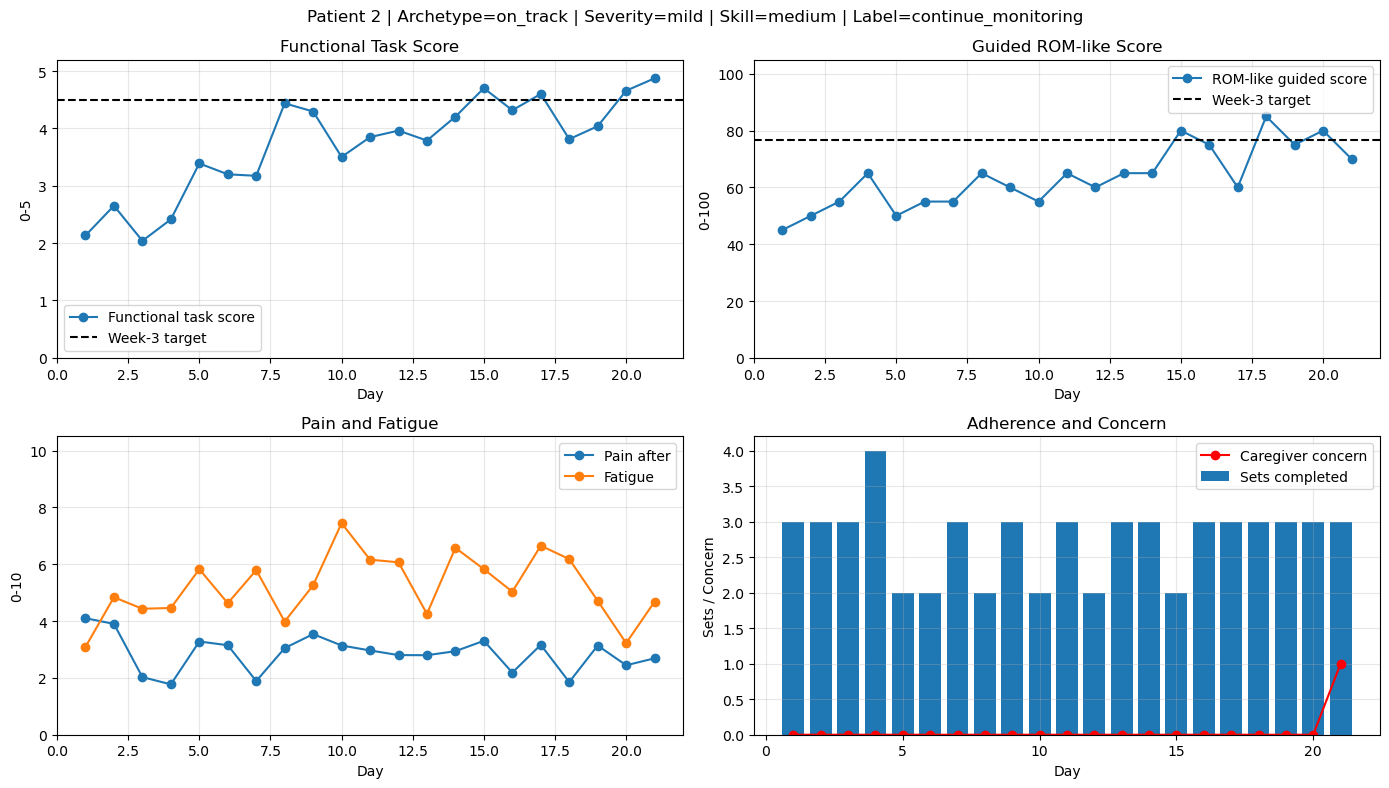

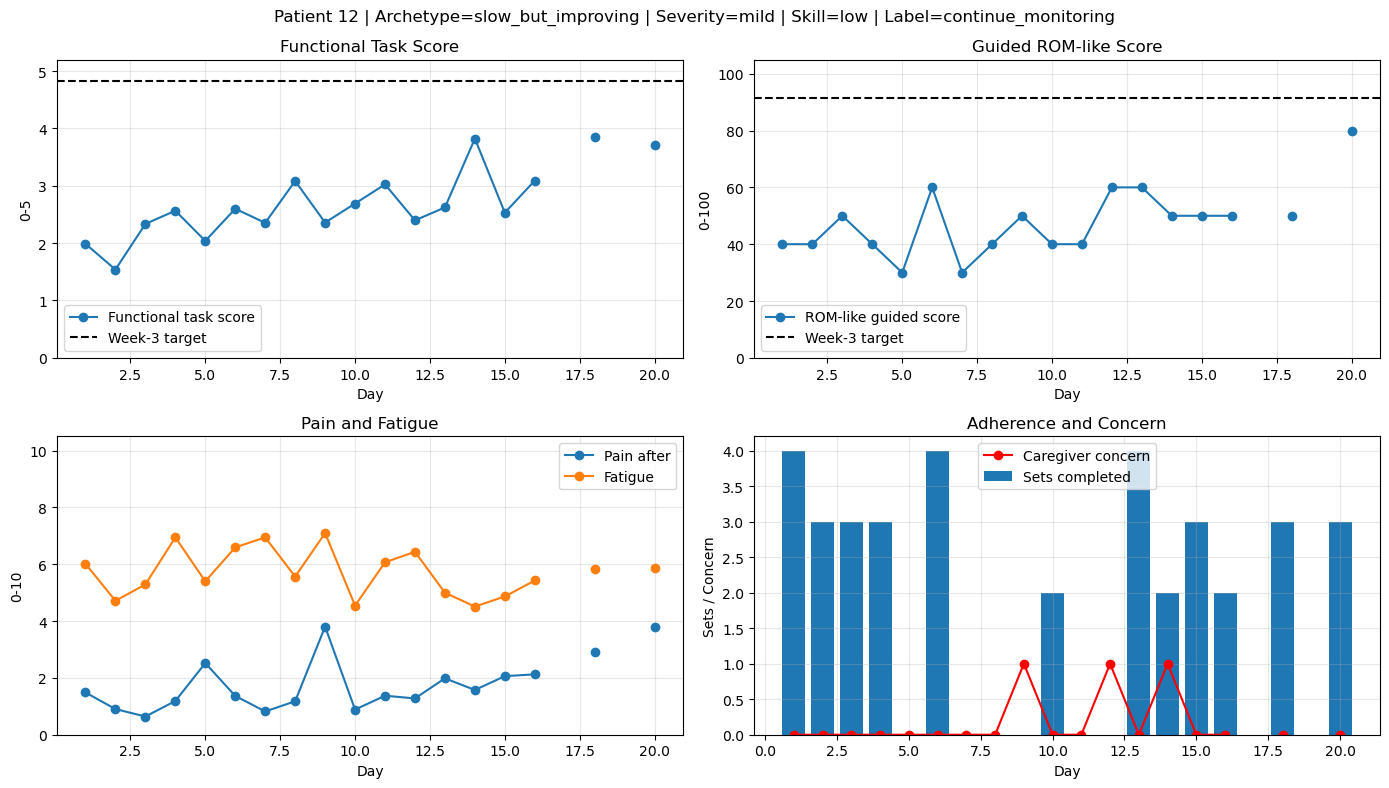

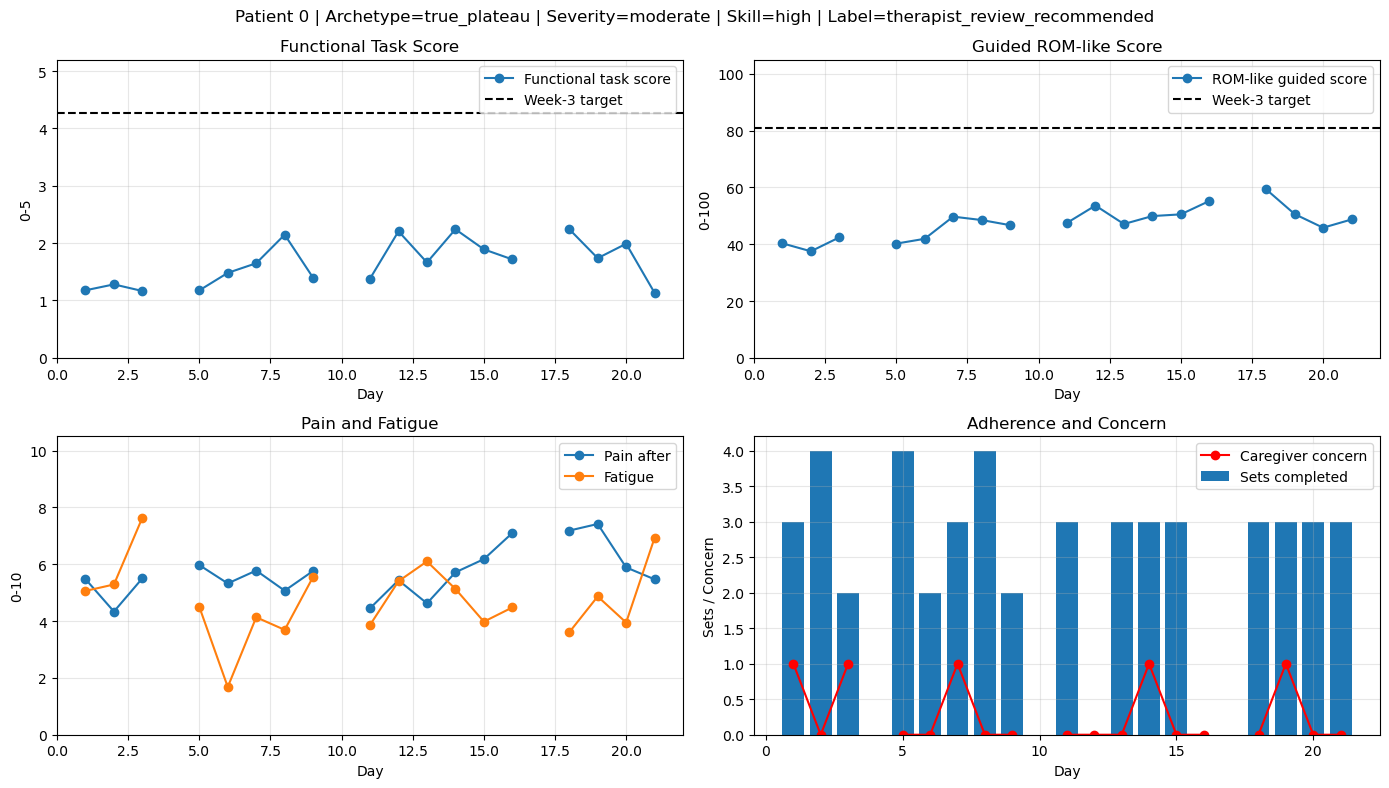

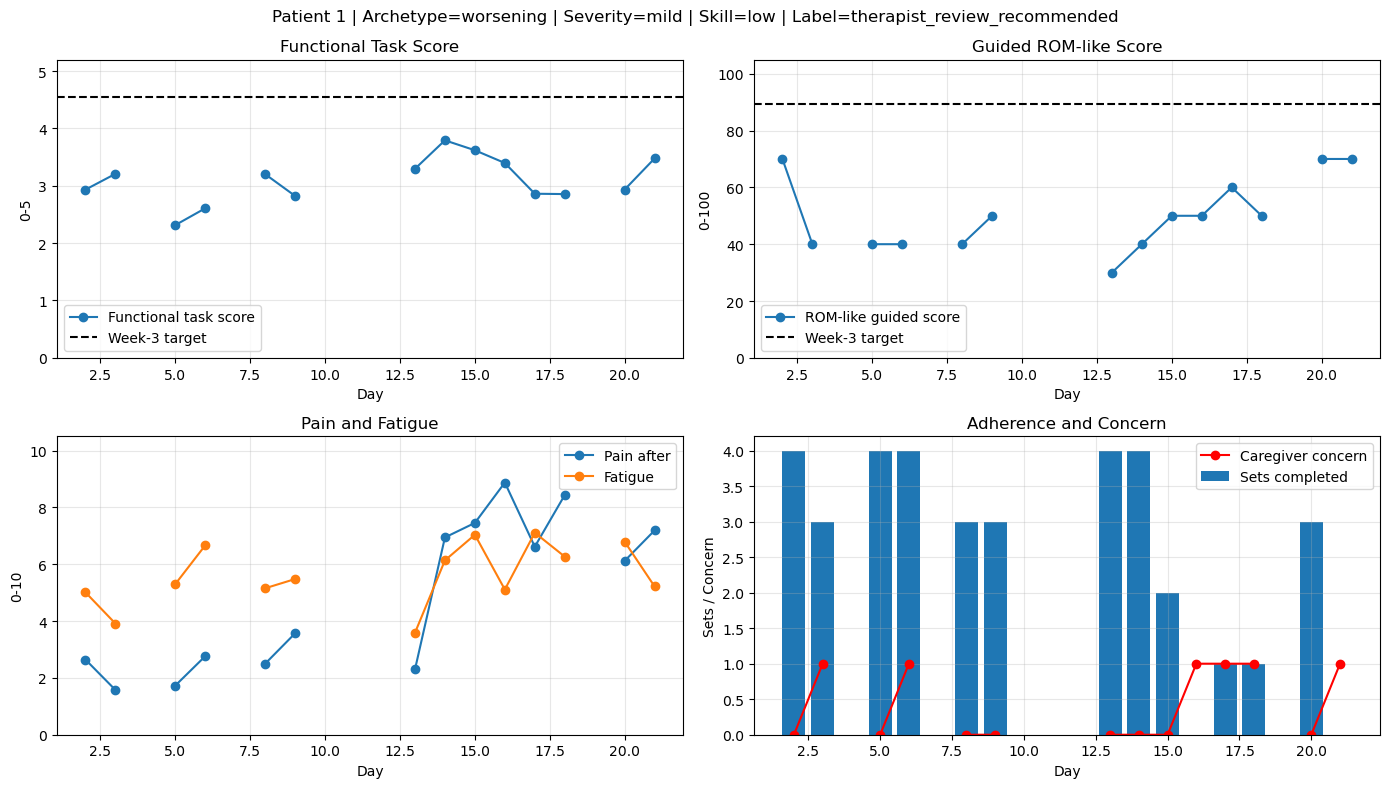

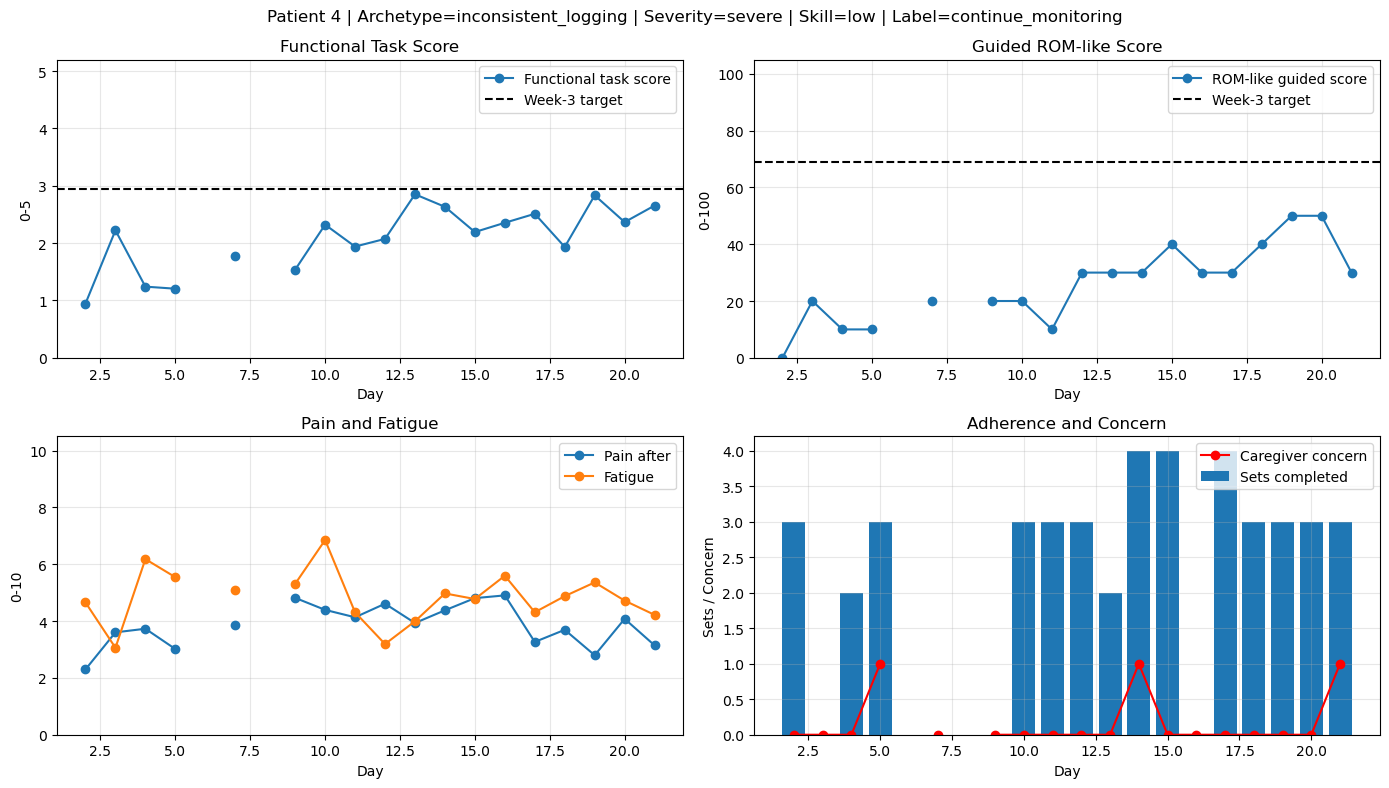

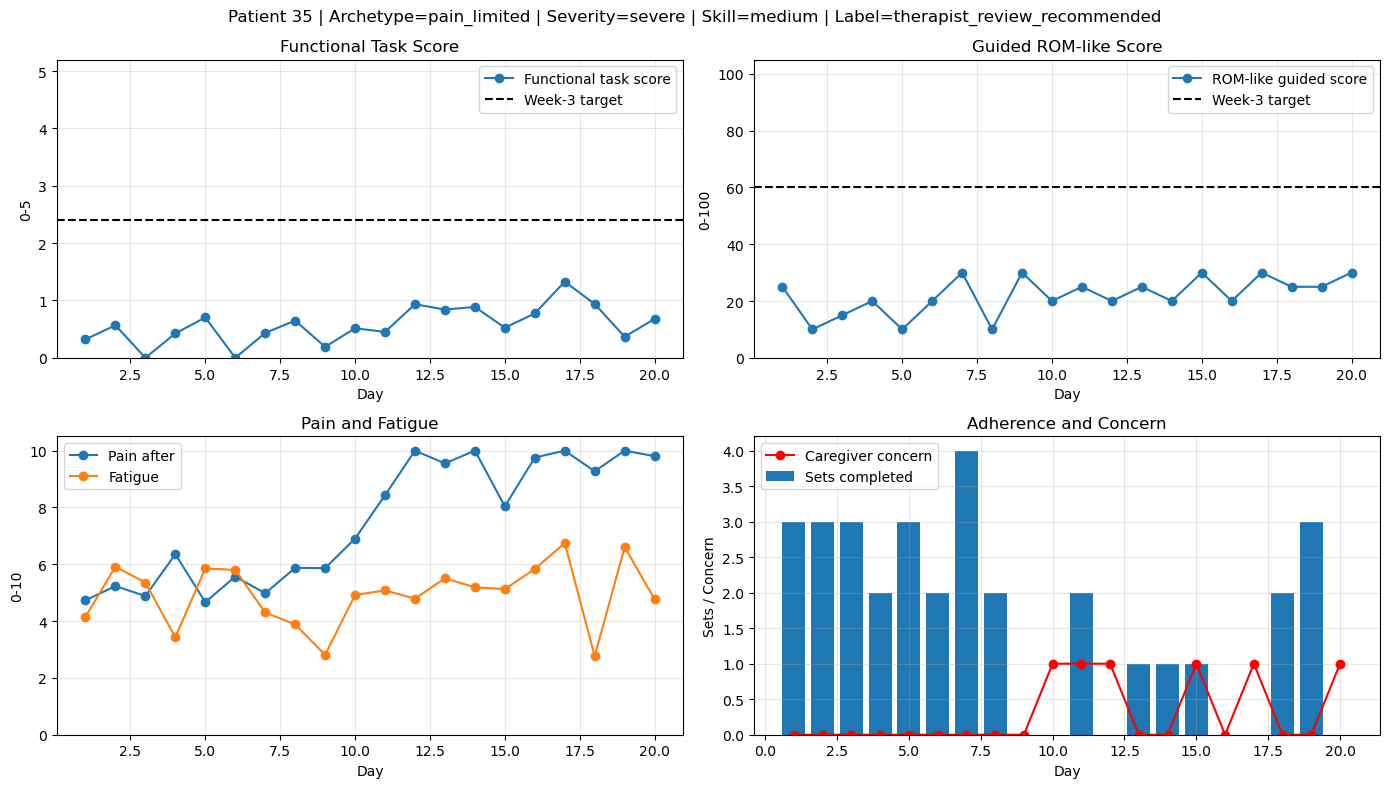

In [7]:

def plot_patient_daily(patient_id):
    p = profiles_df.loc[profiles_df["patient_id"] == patient_id].iloc[0]
    d = daily_df[daily_df["patient_id"] == patient_id].copy()
    label = labels_df.loc[labels_df["patient_id"] == patient_id, "label"].iloc[0]

    days = d["day"].values

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    plt.plot(days, d["functional_task_score"], marker="o", label="Functional task score")
    plt.axhline(p["target_function_wk3"], linestyle="--", color="black", label="Week-3 target")
    plt.ylim(0, 5.2)
    plt.title("Functional Task Score")
    plt.xlabel("Day")
    plt.ylabel("0-5")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(days, d["rom_score"], marker="o", label="ROM-like guided score")
    plt.axhline(p["target_rom_wk3"], linestyle="--", color="black", label="Week-3 target")
    plt.ylim(0, 105)
    plt.title("Guided ROM-like Score")
    plt.xlabel("Day")
    plt.ylabel("0-100")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(days, d["pain_after"], marker="o", label="Pain after")
    plt.plot(days, d["fatigue"], marker="o", label="Fatigue")
    plt.ylim(0, 10.5)
    plt.title("Pain and Fatigue")
    plt.xlabel("Day")
    plt.ylabel("0-10")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.bar(days, d["sets_completed"], label="Sets completed")
    plt.plot(days, d["caregiver_concern"], marker="o", color="red", label="Caregiver concern")
    plt.title("Adherence and Concern")
    plt.xlabel("Day")
    plt.ylabel("Sets / Concern")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.suptitle(
        f"Patient {patient_id} | Archetype={p['archetype']} | "
        f"Severity={p['severity']} | Skill={p['caregiver_skill']} | "
        f"Label={LABELS[label]}"
    )

    plt.tight_layout()
    plt.show()

for arch in TRAJECTORY_ARCHETYPES:
    pid = profiles_df[profiles_df["archetype"] == arch]["patient_id"].iloc[0]
    plot_patient_daily(pid)

In [8]:
def nans_to_zero(x):
    if np.isnan(x):
        return 0.0
    return float(x)

def proportion_true(values, condition_func):
    arr = np.array(values, dtype=float)
    valid = ~np.isnan(arr)
    if valid.sum() == 0:
        return 0.0
    return float(np.mean(condition_func(arr[valid])))

def last_n_values(values, n):
    return np.array(values, dtype=float)[-n:]

def avg_last_n(values, n):
    arr = last_n_values(values, n)
    if np.all(np.isnan(arr)):
        return np.nan
    return float(np.nanmean(arr))

def sum_last_n(values, n):
    arr = last_n_values(values, n)
    if np.all(np.isnan(arr)):
        return 0.0
    return float(np.nansum(arr))

def count_condition_last_n(values, n, condition_func):
    arr = last_n_values(values, n)
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        return 0
    return int(np.sum(condition_func(valid)))

def make_features_for_patient(patient_id):
    """
    Build model features from app-available data only.
    """
    d = daily_df[daily_df["patient_id"] == patient_id].sort_values("day")
    p = profiles_df[profiles_df["patient_id"] == patient_id].iloc[0]
    label = int(labels_df.loc[labels_df["patient_id"] == patient_id, "label"].iloc[0])

    function_values = d["functional_task_score"].values.astype(float)
    rom_values = d["rom_score"].values.astype(float)
    pain_before = d["pain_before"].values.astype(float)
    pain_after = d["pain_after"].values.astype(float)
    fatigue = d["fatigue"].values.astype(float)
    therapy_completed = d["therapy_completed"].values.astype(float)
    sets_completed = d["sets_completed"].values.astype(float)
    assistance = d["assistance_required"].values.astype(float)
    concern = d["caregiver_concern"].values.astype(float)
    log_entered = d["log_entered"].values.astype(float)

    target_function = float(p["target_function_wk3"])
    target_rom = float(p["target_rom_wk3"])

    function_final_3 = avg_last_n(function_values, 3)
    rom_final_3 = avg_last_n(rom_values, 3)

    function_gap = (
        (target_function - function_final_3) / max(target_function, 0.1)
        if not np.isnan(function_final_3)
        else 1.0
    )

    rom_gap = (
        (target_rom - rom_final_3) / max(target_rom, 1.0)
        if not np.isnan(rom_final_3)
        else 1.0
    )

    features = {
        # Care plan target context.
        "target_function_wk3": target_function,
        "target_rom_wk3": target_rom,

        # Simple patient context that the app would likely know.
        "age": float(p["age"]),
        "severity_mild": int(p["severity"] == "mild"),
        "severity_moderate": int(p["severity"] == "moderate"),
        "severity_severe": int(p["severity"] == "severe"),

        # Logging completeness.
        "logs_entered_21d": int(np.nansum(log_entered)),
        "missing_logs_21d": int(DAYS - np.nansum(log_entered)),
        "missing_logs_7d": int(7 - np.nansum(log_entered[-7:])),

        # Adherence.
        "therapy_completed_days_21d": int(np.nansum(therapy_completed == 1)),
        "therapy_completed_days_7d": int(np.nansum(therapy_completed[-7:] == 1)),
        "missed_therapy_days_21d": int(np.nansum(therapy_completed == 0)),
        "missed_therapy_days_7d": int(np.nansum(therapy_completed[-7:] == 0)),
        "sets_completed_total_21d": float(np.nansum(sets_completed)),
        "sets_completed_avg_7d": nans_to_zero(avg_last_n(sets_completed, 7)),

        # Pain and fatigue.
        "pain_after_avg_3d": nans_to_zero(avg_last_n(pain_after, 3)),
        "pain_after_avg_7d": nans_to_zero(avg_last_n(pain_after, 7)),
        "pain_after_change_7d": nans_to_zero(avg_last_n(pain_after, 3) - avg_last_n(pain_after[:7], 7))
            if not np.isnan(avg_last_n(pain_after, 3)) and not np.isnan(avg_last_n(pain_after[:7], 7))
            else 0.0,
        "high_pain_days_21d": count_condition_last_n(pain_after, 21, lambda x: x >= 7),
        "high_pain_days_7d": count_condition_last_n(pain_after, 7, lambda x: x >= 7),

        "fatigue_avg_3d": nans_to_zero(avg_last_n(fatigue, 3)),
        "fatigue_avg_7d": nans_to_zero(avg_last_n(fatigue, 7)),
        "high_fatigue_days_21d": count_condition_last_n(fatigue, 21, lambda x: x >= 8),
        "high_fatigue_days_7d": count_condition_last_n(fatigue, 7, lambda x: x >= 8),

        # Assistance and caregiver concern.
        "assistance_avg_7d": nans_to_zero(avg_last_n(assistance, 7)),
        "full_assist_days_21d": count_condition_last_n(assistance, 21, lambda x: x >= 2),
        "full_assist_days_7d": count_condition_last_n(assistance, 7, lambda x: x >= 2),
        "caregiver_concern_days_21d": int(np.nansum(concern == 1)),
        "caregiver_concern_days_7d": int(np.nansum(concern[-7:] == 1)),

        # Functional progress.
        "function_final_3d": nans_to_zero(function_final_3),
        "function_initial_3d": nans_to_zero(avg_last_n(function_values[:3], 3)),
        "function_change_21d": nans_to_zero(function_final_3 - avg_last_n(function_values[:3], 3))
            if not np.isnan(function_final_3) and not np.isnan(avg_last_n(function_values[:3], 3))
            else 0.0,
        "function_slope_21d": compute_slope(function_values),
        "function_slope_9d": compute_last_n_slope(function_values, 9),
        "function_gap_to_target": float(function_gap),
        "function_plateau_days": count_days_without_meaningful_improvement(function_values, min_delta=0.10),

        # Optional guided ROM-like progress.
        # This is realistic only if you collect it with a guided tool.
        "rom_final_3d": nans_to_zero(rom_final_3),
        "rom_initial_3d": nans_to_zero(avg_last_n(rom_values[:3], 3)),
        "rom_change_21d": nans_to_zero(rom_final_3 - avg_last_n(rom_values[:3], 3))
            if not np.isnan(rom_final_3) and not np.isnan(avg_last_n(rom_values[:3], 3))
            else 0.0,
        "rom_slope_21d": compute_slope(rom_values),
        "rom_slope_9d": compute_last_n_slope(rom_values, 9),
        "rom_gap_to_target": float(rom_gap),
        "rom_plateau_days": count_days_without_meaningful_improvement(rom_values, min_delta=1.5),

        # Label.
        "label": label,
        "patient_id": patient_id
    }

    return features

feature_rows = [make_features_for_patient(pid) for pid in range(N_PATIENTS)]
features_df = pd.DataFrame(feature_rows)

print(features_df.shape)
display(features_df.head())
display(features_df.describe())

(10000, 45)


,target_function_wk3,target_rom_wk3,age,severity_mild,severity_moderate,severity_severe,logs_entered_21d,missing_logs_21d,missing_logs_7d,therapy_completed_days_21d,...,function_plateau_days,rom_final_3d,rom_initial_3d,rom_change_21d,rom_slope_21d,rom_slope_9d,rom_gap_to_target,rom_plateau_days,label,patient_id
0,4.260883,80.811066,65.0,0,1,0,18,3,1,16,...,2,48.366667,40.066667,8.300000,0.693247,-0.026667,0.401485,0,1,0
1,4.549227,89.291918,52.0,1,0,0,14,7,1,12,...,0,70.000000,55.000000,15.000000,0.506494,4.500000,0.216054,2,1,1
2,4.498442,76.738406,62.0,1,0,0,21,0,0,21,...,0,75.000000,50.000000,25.000000,1.422078,1.083333,0.022654,2,0,2
3,3.952344,65.373509,73.0,0,1,0,18,3,1,8,...,3,35.000000,40.000000,-5.000000,0.246753,-1.083333,0.464615,0,1,3
4,2.938540,68.788749,55.0,0,0,1,18,3,0,14,...,0,43.333333,10.000000,33.333333,1.993506,1.500000,0.370052,3,0,4


,target_function_wk3,target_rom_wk3,age,severity_mild,severity_moderate,severity_severe,logs_entered_21d,missing_logs_21d,missing_logs_7d,therapy_completed_days_21d,...,function_plateau_days,rom_final_3d,rom_initial_3d,rom_change_21d,rom_slope_21d,rom_slope_9d,rom_gap_to_target,rom_plateau_days,label,patient_id
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.00000
mean,3.747850,73.614458,67.364900,0.34420,0.449100,0.206700,17.909700,3.090300,1.065500,13.772900,...,1.993300,58.438237,35.234242,23.084510,1.273461,8.070934e-01,0.215508,2.158600,0.549500,4999.50000
std,0.740346,12.086704,8.961796,0.47513,0.497427,0.404959,2.415684,2.415684,1.114331,3.478899,...,1.888071,20.745433,14.140428,14.565800,0.745687,1.319276e+00,0.225153,2.054621,0.497569,2886.89568
min,2.000828,45.008792,45.000000,0.00000,0.000000,0.000000,7.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,-35.000000,-1.571429,-5.583333e+00,-0.466860,0.000000,0.000000,0.00000
25%,3.215992,64.594648,61.000000,0.00000,0.000000,0.000000,16.000000,1.000000,0.000000,11.000000,...,0.000000,43.925000,25.262500,12.500000,0.720731,-5.969753e-15,0.046323,0.000000,0.000000,2499.75000
50%,3.861370,75.608212,67.000000,0.00000,0.000000,0.000000,18.000000,3.000000,1.000000,14.000000,...,2.000000,58.333333,35.858333,22.500000,1.240260,7.883333e-01,0.202922,2.000000,1.000000,4999.50000
75%,4.284589,82.901588,73.000000,1.00000,1.000000,0.000000,20.000000,5.000000,2.000000,16.000000,...,3.000000,73.333333,45.000000,33.333333,1.802219,1.638889e+00,0.357329,3.000000,1.000000,7499.25000
max,4.999510,94.996368,92.000000,1.00000,1.000000,1.000000,21.000000,14.000000,6.000000,21.000000,...,13.000000,100.000000,90.000000,70.833333,3.742424,6.666667e+00,1.000000,15.000000,1.000000,9999.00000


In [9]:
excluded_cols = ["label", "patient_id"]
feature_cols = [c for c in features_df.columns if c not in excluded_cols]

print("Number of model features:", len(feature_cols))
print("\nModel feature columns:")
for c in feature_cols:
    print("-", c)

with open(os.path.join(OUTPUT_DIR, "feature_columns.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

Number of model features: 43

Model feature columns:
- target_function_wk3
- target_rom_wk3
- age
- severity_mild
- severity_moderate
- severity_severe
- logs_entered_21d
- missing_logs_21d
- missing_logs_7d
- therapy_completed_days_21d
- therapy_completed_days_7d
- missed_therapy_days_21d
- missed_therapy_days_7d
- sets_completed_total_21d
- sets_completed_avg_7d
- pain_after_avg_3d
- pain_after_avg_7d
- pain_after_change_7d
- high_pain_days_21d
- high_pain_days_7d
- fatigue_avg_3d
- fatigue_avg_7d
- high_fatigue_days_21d
- high_fatigue_days_7d
- assistance_avg_7d
- full_assist_days_21d
- full_assist_days_7d
- caregiver_concern_days_21d
- caregiver_concern_days_7d
- function_final_3d
- function_initial_3d
- function_change_21d
- function_slope_21d
- function_slope_9d
- function_gap_to_target
- function_plateau_days
- rom_final_3d
- rom_initial_3d
- rom_change_21d
- rom_slope_21d
- rom_slope_9d
- rom_gap_to_target
- rom_plateau_days


Rule-based performance:
                              precision    recall  f1-score   support

         continue_monitoring       0.56      0.98      0.71      4505
therapist_review_recommended       0.96      0.35      0.52      5495

                    accuracy                           0.64     10000
                   macro avg       0.76      0.67      0.61     10000
                weighted avg       0.78      0.64      0.60     10000



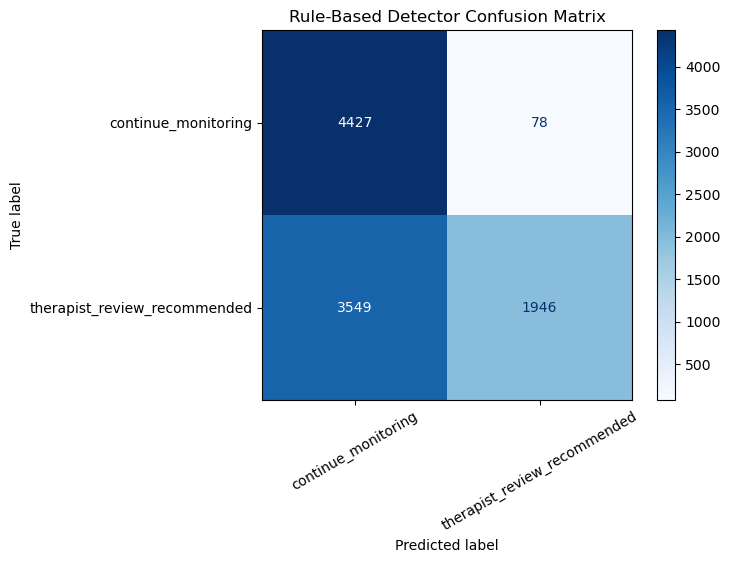

In [10]:
def clinical_rule_predict(row):
    """
    Transparent rule:
    Recommend therapist review if there is target gap plus plateau/worsening,
    or high pain/concern with low function, or insufficient monitoring.
    """

    # Main James-like case:
    # gap to target + plateau.
    if (
        row["rom_gap_to_target"] >= 0.25
        and row["rom_plateau_days"] >= 7
        and row["rom_slope_9d"] <= 0.75
    ):
        return 1

    if (
        row["function_gap_to_target"] >= 0.25
        and row["function_plateau_days"] >= 7
        and row["function_slope_9d"] <= 0.08
    ):
        return 1

    # Worsening trend.
    if row["rom_slope_9d"] < -0.5 and row["rom_gap_to_target"] >= 0.15:
        return 1

    if row["function_slope_9d"] < -0.08 and row["function_gap_to_target"] >= 0.15:
        return 1

    # Pain-limited or caregiver concern cases.
    if (
        row["high_pain_days_7d"] >= 3
        and row["therapy_completed_days_7d"] <= 3
        and row["caregiver_concern_days_7d"] >= 2
    ):
        return 1

    # Insufficient monitoring with concern signals.
    if row["missing_logs_7d"] >= 4 and row["caregiver_concern_days_21d"] >= 3:
        return 1

    return 0

features_df["rule_pred"] = features_df.apply(clinical_rule_predict, axis=1)

print("Rule-based performance:")
print(classification_report(
    features_df["label"],
    features_df["rule_pred"],
    target_names=[LABELS[0], LABELS[1]]
))

cm = confusion_matrix(features_df["label"], features_df["rule_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=[LABELS[0], LABELS[1]])
disp.plot(cmap="Blues", values_format="d")
plt.title("Rule-Based Detector Confusion Matrix")
plt.xticks(rotation=30)
plt.show()

In [11]:
X = features_df[feature_cols].values.astype(float)
y = features_df["label"].values.astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (7000, 43)
Val: (1500, 43)
Test: (1500, 43)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=2000,
    solver="lbfgs"
)

log_reg.fit(X_train_scaled, y_train)

log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
log_preds = (log_probs >= 0.5).astype(int)

print("Logistic regression performance:")
print(classification_report(
    y_test,
    log_preds,
    target_names=[LABELS[0], LABELS[1]]
))

print("AUC:", roc_auc_score(y_test, log_probs))
print("Brier score:", brier_score_loss(y_test, log_probs))

Logistic regression performance:
                              precision    recall  f1-score   support

         continue_monitoring       0.89      0.92      0.91       676
therapist_review_recommended       0.94      0.91      0.92       824

                    accuracy                           0.92      1500
                   macro avg       0.91      0.92      0.91      1500
                weighted avg       0.92      0.92      0.92      1500

AUC: 0.9689456827712989
Brier score: 0.06655206858755944


In [13]:
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=80,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

tree_probs = tree.predict_proba(X_test)[:, 1]
tree_preds = (tree_probs >= 0.5).astype(int)

print("Decision tree performance:")
print(classification_report(
    y_test,
    tree_preds,
    target_names=[LABELS[0], LABELS[1]]
))

print("AUC:", roc_auc_score(y_test, tree_probs))

tree_rules = export_text(tree, feature_names=feature_cols)
print(tree_rules)

with open(os.path.join(OUTPUT_DIR, "decision_tree_rules.txt"), "w") as f:
    f.write(tree_rules)

Decision tree performance:
                              precision    recall  f1-score   support

         continue_monitoring       0.87      0.92      0.90       676
therapist_review_recommended       0.93      0.89      0.91       824

                    accuracy                           0.90      1500
                   macro avg       0.90      0.91      0.90      1500
                weighted avg       0.91      0.90      0.90      1500

AUC: 0.9549857815821221
|--- function_gap_to_target <= 0.20
|   |--- rom_gap_to_target <= 0.25
|   |   |--- high_pain_days_21d <= 3.50
|   |   |   |--- rom_slope_9d <= -0.50
|   |   |   |   |--- class: 0
|   |   |   |--- rom_slope_9d >  -0.50
|   |   |   |   |--- class: 0
|   |   |--- high_pain_days_21d >  3.50
|   |   |   |--- caregiver_concern_days_21d <= 3.50
|   |   |   |   |--- class: 0
|   |   |   |--- caregiver_concern_days_21d >  3.50
|   |   |   |   |--- class: 1
|   |--- rom_gap_to_target >  0.25
|   |   |--- caregiver_concern_days_21

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("Random forest performance:")
print(classification_report(
    y_test,
    rf_preds,
    target_names=[LABELS[0], LABELS[1]]
))

print("AUC:", roc_auc_score(y_test, rf_probs))
print("Brier score:", brier_score_loss(y_test, rf_probs))

Random forest performance:
                              precision    recall  f1-score   support

         continue_monitoring       0.90      0.93      0.91       676
therapist_review_recommended       0.94      0.91      0.93       824

                    accuracy                           0.92      1500
                   macro avg       0.92      0.92      0.92      1500
                weighted avg       0.92      0.92      0.92      1500

AUC: 0.9808266789222726
Brier score: 0.060567579989755566


In [15]:
def metrics_row(name, y_true, probs_or_preds, is_probs=True, threshold=0.5):
    if is_probs:
        probs = probs_or_preds
        preds = (probs >= threshold).astype(int)
        auc = roc_auc_score(y_true, probs)
        brier = brier_score_loss(y_true, probs)
    else:
        preds = probs_or_preds
        auc = np.nan
        brier = np.nan

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc": auc,
        "brier_score": brier
    }

# Need rule predictions on test set.
test_indices = features_df.iloc[y_test.index] if hasattr(y_test, "index") else None

In [16]:
indices = np.arange(len(features_df))

idx_train, idx_temp, y_train2, y_temp2 = train_test_split(
    indices,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

idx_val, idx_test, y_val2, y_test2 = train_test_split(
    idx_temp,
    y_temp2,
    test_size=0.50,
    stratify=y_temp2,
    random_state=42
)

rule_test_preds = features_df.iloc[idx_test]["rule_pred"].values

comparison = pd.DataFrame([
    metrics_row("clinical_rules", y_test, rule_test_preds, is_probs=False),
    metrics_row("logistic_regression", y_test, log_probs, is_probs=True),
    metrics_row("decision_tree", y_test, tree_probs, is_probs=True),
    metrics_row("random_forest", y_test, rf_probs, is_probs=True),
])

display(comparison)

comparison.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)

,model,accuracy,precision,recall,f1,auc,brier_score
0,clinical_rules,0.630667,0.956081,0.343447,0.505357,NaN,NaN
1,logistic_regression,0.915333,0.935081,0.908981,0.921846,0.968946,0.066552
2,decision_tree,0.904000,0.931472,0.890777,0.910670,0.954986,0.073840
3,random_forest,0.920000,0.938903,0.913835,0.926199,0.980827,0.060568


,threshold,accuracy,precision,recall,f1
0,0.05,0.790667,0.728905,0.985437,0.837977
1,0.10,0.836000,0.780039,0.976942,0.867457
2,0.15,0.870667,0.825413,0.969660,0.891741
3,0.20,0.886000,0.851453,0.959951,0.902453
4,0.25,0.893333,0.869710,0.947816,0.907085
5,0.30,0.902000,0.888634,0.939320,0.913274
6,0.35,0.910667,0.906840,0.933252,0.919856
7,0.40,0.914000,0.919180,0.924757,0.921960
8,0.45,0.916667,0.927785,0.919903,0.923827
9,0.50,0.915333,0.935081,0.908981,0.921846


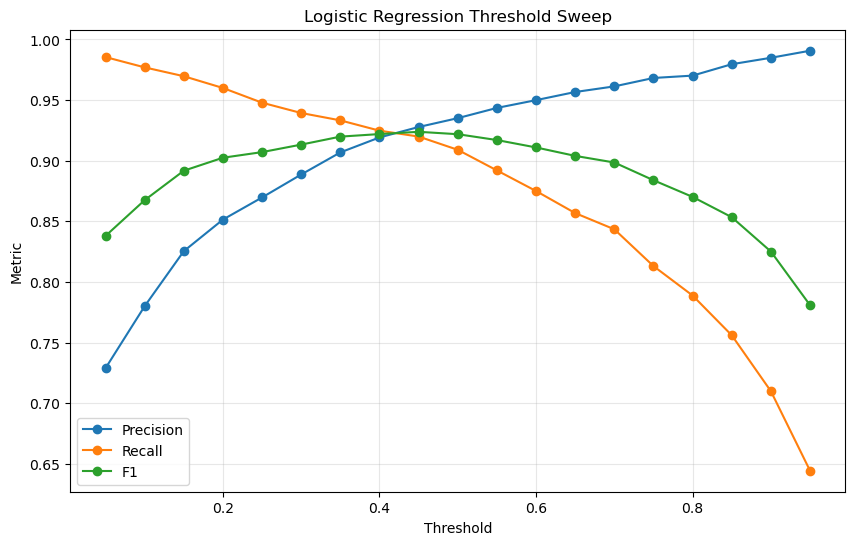

Selected threshold: 0.6500000000000001


threshold    0.650000
accuracy     0.900000
precision    0.956640
recall       0.856796
f1           0.903969
Name: 12, dtype: float64

In [17]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for threshold in thresholds:
    preds = (log_probs >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Logistic Regression Threshold Sweep")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Example operating point: choose highest precision while recall >= 0.85.
candidate = threshold_df[threshold_df["recall"] >= 0.85]

if len(candidate) > 0:
    selected = candidate.sort_values("precision", ascending=False).iloc[0]
else:
    selected = threshold_df.sort_values("f1", ascending=False).iloc[0]

SELECTED_THRESHOLD = float(selected["threshold"])
print("Selected threshold:", SELECTED_THRESHOLD)
display(selected)

<Figure size 600x600 with 0 Axes>

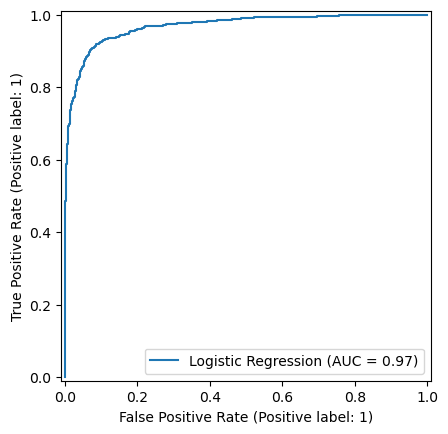

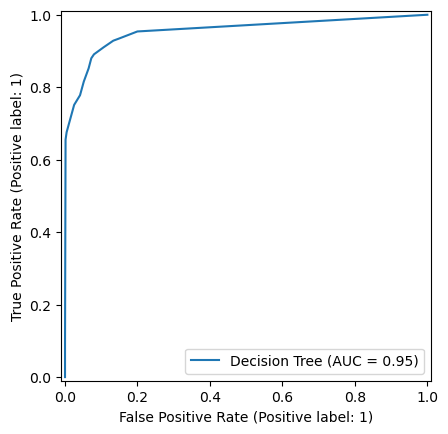

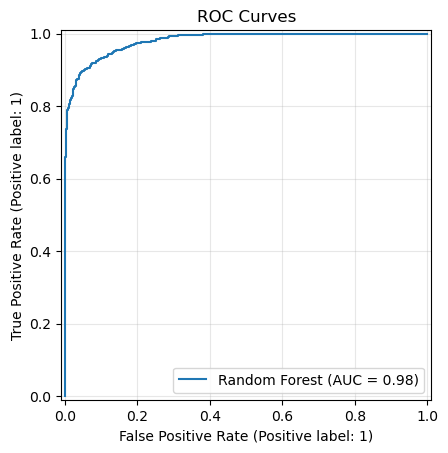

<Figure size 600x600 with 0 Axes>

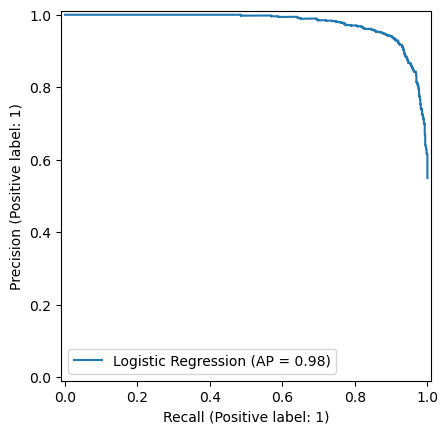

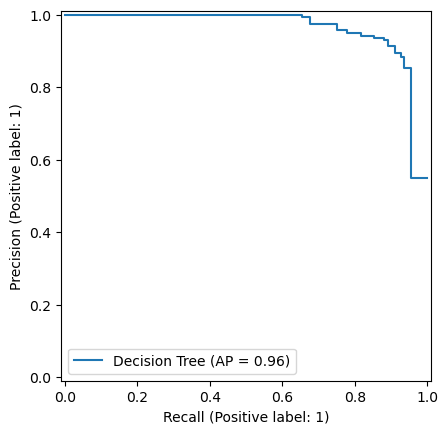

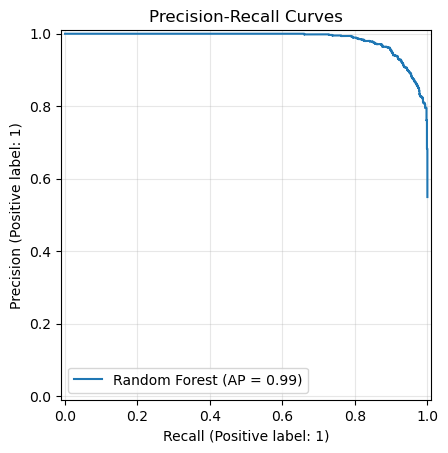

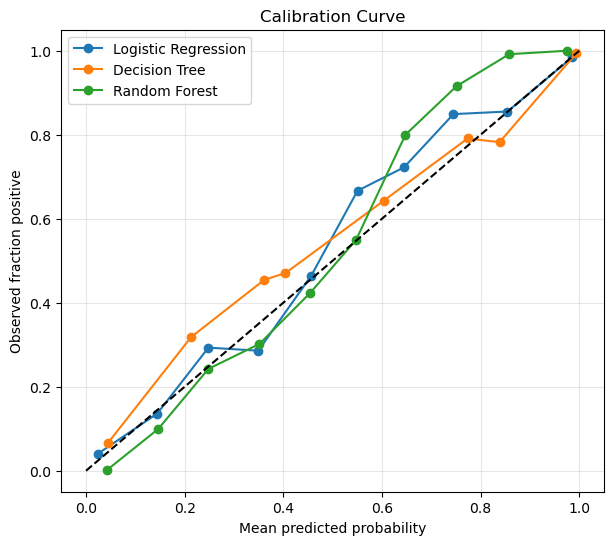

In [18]:
plt.figure(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, log_probs, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, tree_probs, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test, rf_probs, name="Random Forest")
plt.title("ROC Curves")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
PrecisionRecallDisplay.from_predictions(y_test, log_probs, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, tree_probs, name="Decision Tree")
PrecisionRecallDisplay.from_predictions(y_test, rf_probs, name="Random Forest")
plt.title("Precision-Recall Curves")
plt.grid(True, alpha=0.3)
plt.show()

# Calibration curve.
plt.figure(figsize=(7, 6))
for name, probs in [
    ("Logistic Regression", log_probs),
    ("Decision Tree", tree_probs),
    ("Random Forest", rf_probs),
]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction positive")
plt.title("Calibration Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

,feature,coefficient
41,rom_gap_to_target,1.659184
25,full_assist_days_21d,1.527536
15,pain_after_avg_3d,1.351805
27,caregiver_concern_days_21d,1.338367
0,target_function_wk3,1.156828
18,high_pain_days_21d,0.966526
34,function_gap_to_target,0.845607
24,assistance_avg_7d,0.771983
20,fatigue_avg_3d,0.760970
29,function_final_3d,0.710578


,feature,coefficient
8,missing_logs_7d,0.019021
4,severity_moderate,0.000834
2,age,-0.036749
3,severity_mild,-0.087845
28,caregiver_concern_days_7d,-0.093841
17,pain_after_change_7d,-0.094356
12,missed_therapy_days_7d,-0.110478
6,logs_entered_21d,-0.159843
13,sets_completed_total_21d,-0.176915
14,sets_completed_avg_7d,-0.187412


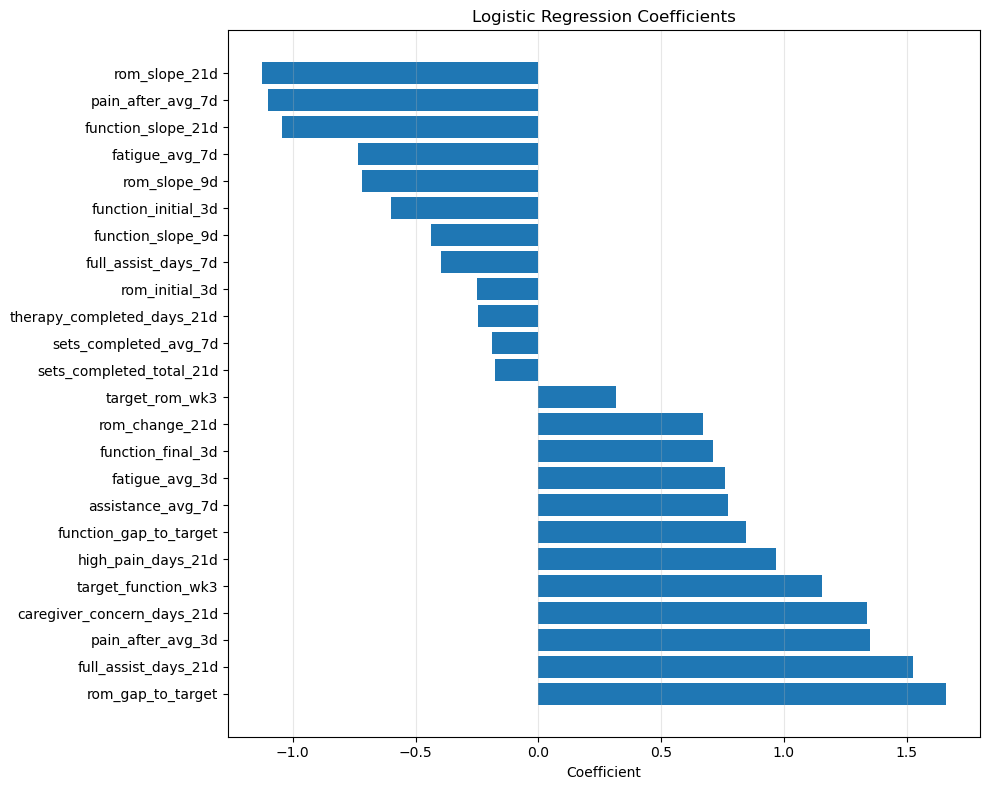

,feature,importance
34,function_gap_to_target,0.184914
41,rom_gap_to_target,0.178475
36,rom_final_3d,0.116100
29,function_final_3d,0.093436
39,rom_slope_21d,0.056063
24,assistance_avg_7d,0.049610
27,caregiver_concern_days_21d,0.046590
38,rom_change_21d,0.044151
32,function_slope_21d,0.028170
18,high_pain_days_21d,0.027820


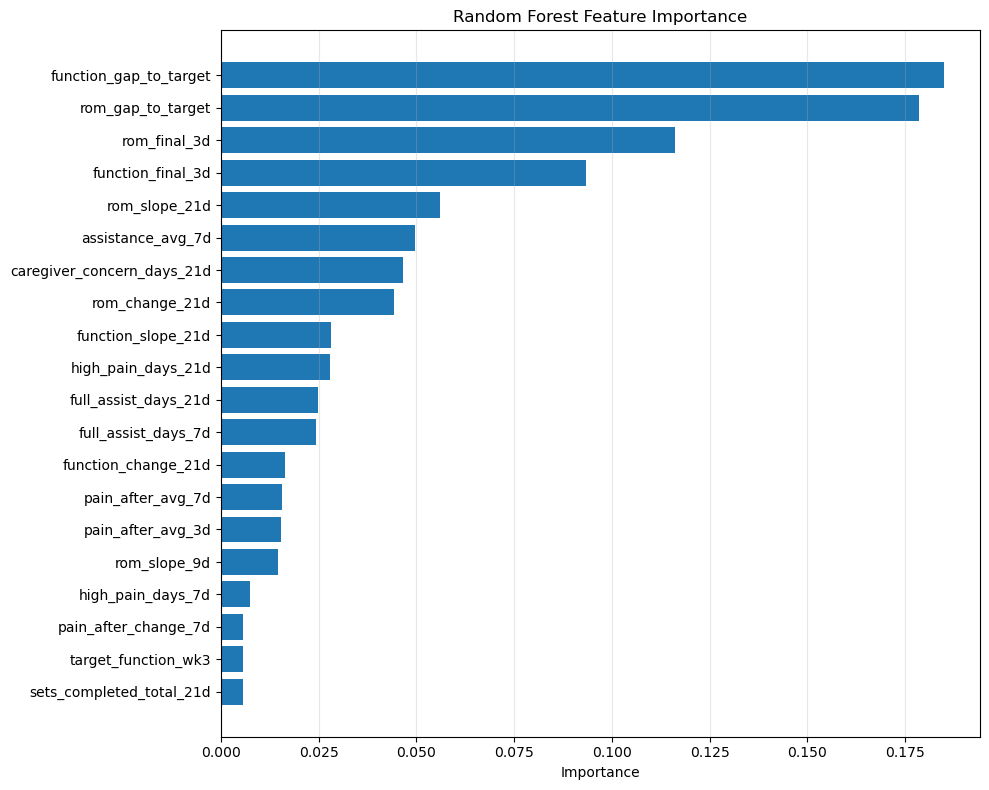

In [19]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", ascending=False)

display(coef_df.head(20))
display(coef_df.tail(20))

plt.figure(figsize=(10, 8))
top_coef = pd.concat([coef_df.head(12), coef_df.tail(12)])
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

coef_df.to_csv(os.path.join(OUTPUT_DIR, "logistic_regression_coefficients.csv"), index=False)

# Random forest importance.
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(25))

plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(20)["feature"][::-1], importance_df.head(20)["importance"][::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

importance_df.to_csv(os.path.join(OUTPUT_DIR, "random_forest_feature_importance.csv"), index=False)

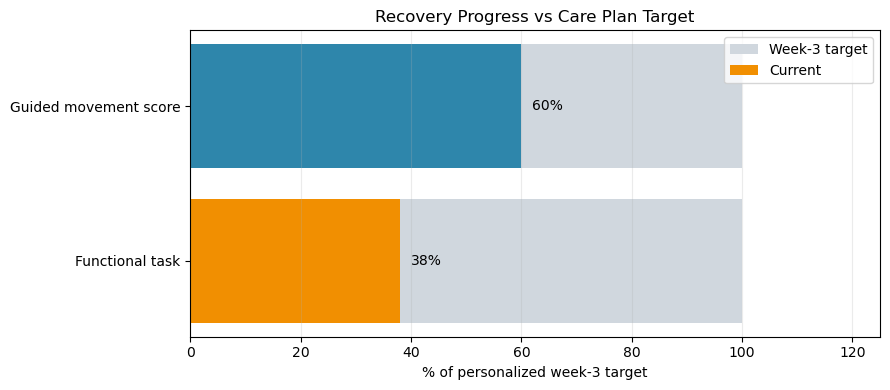

Plain-language message:
Recovery appears below the expected care-plan target. A therapist review may be helpful.


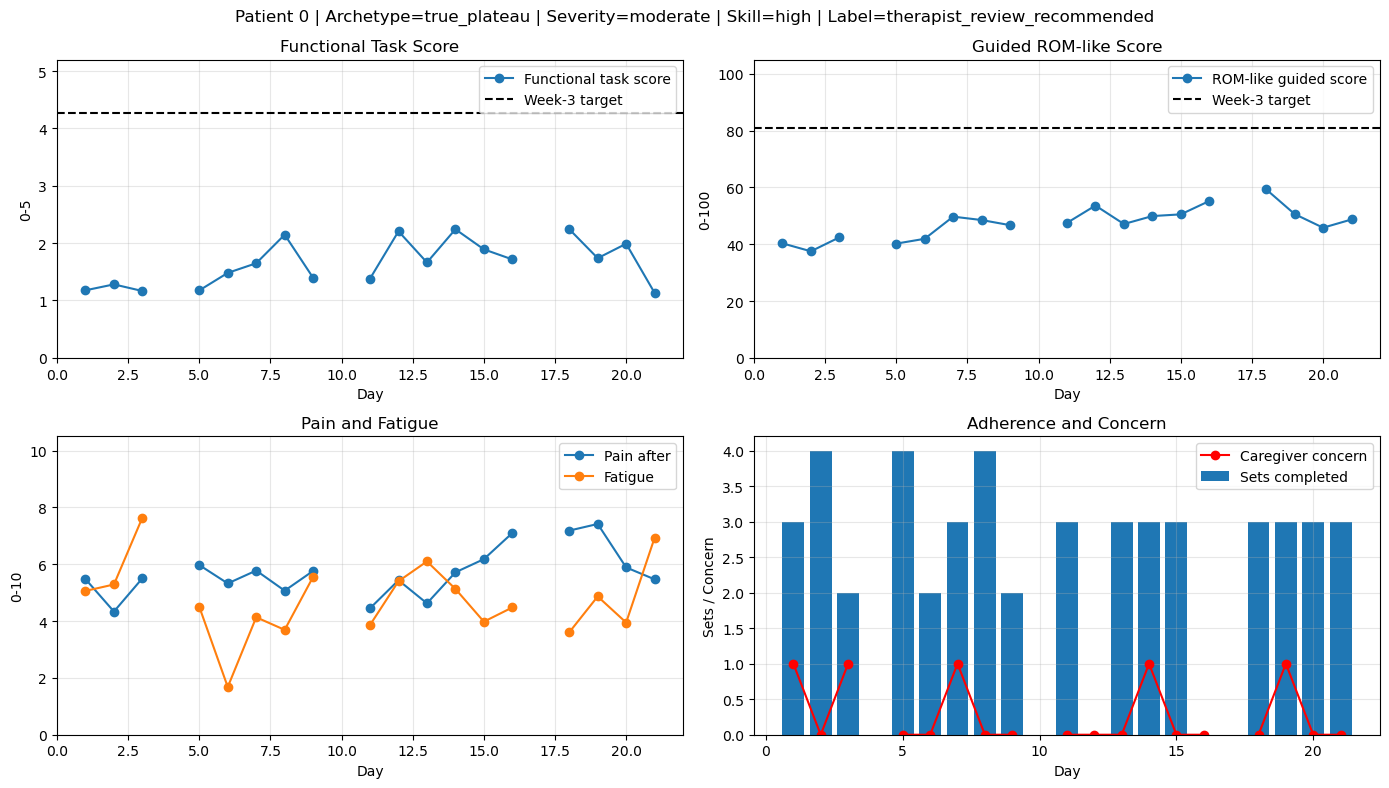

In [20]:
def caregiver_visualization(patient_id):
    p = profiles_df[profiles_df["patient_id"] == patient_id].iloc[0]
    d = daily_df[daily_df["patient_id"] == patient_id].sort_values("day")
    row = features_df[features_df["patient_id"] == patient_id].iloc[0]

    function_actual = row["function_final_3d"]
    function_target = row["target_function_wk3"]
    function_pct = 100 * function_actual / max(function_target, 0.1)

    rom_actual = row["rom_final_3d"]
    rom_target = row["target_rom_wk3"]
    rom_pct = 100 * rom_actual / max(rom_target, 1.0)

    function_pct = np.clip(function_pct, 0, 120)
    rom_pct = np.clip(rom_pct, 0, 120)

    plt.figure(figsize=(9, 4))
    labels = ["Functional task", "Guided movement score"]
    actuals = [function_pct, rom_pct]

    plt.barh(labels, [100, 100], color="#d0d7de", label="Week-3 target")
    plt.barh(labels, actuals, color=["#F18F01", "#2E86AB"], label="Current")

    for i, v in enumerate(actuals):
        plt.text(v + 2, i, f"{v:.0f}%", va="center")

    plt.xlim(0, 125)
    plt.xlabel("% of personalized week-3 target")
    plt.title("Recovery Progress vs Care Plan Target")
    plt.grid(axis="x", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if row["rom_gap_to_target"] >= 0.25 or row["function_gap_to_target"] >= 0.25:
        print("Plain-language message:")
        print("Recovery appears below the expected care-plan target. A therapist review may be helpful.")
    elif row["caregiver_concern_days_7d"] >= 2:
        print("Plain-language message:")
        print("Recent caregiver concerns were logged. Consider checking in with the care team.")
    else:
        print("Plain-language message:")
        print("Progress appears within the expected monitoring range.")

# Show one positive case.
positive_pid = features_df[features_df["label"] == 1]["patient_id"].iloc[0]
caregiver_visualization(positive_pid)
plot_patient_daily(positive_pid)

{
  "target_function_wk3": 3.8,
  "target_rom_wk3": 85.0,
  "age": 67.0,
  "severity_mild": 0,
  "severity_moderate": 1,
  "severity_severe": 0,
  "logs_entered_21d": 21,
  "missing_logs_21d": 0,
  "missing_logs_7d": 0,
  "therapy_completed_days_21d": 21,
  "therapy_completed_days_7d": 7,
  "missed_therapy_days_21d": 0,
  "missed_therapy_days_7d": 0,
  "sets_completed_total_21d": 63.0,
  "sets_completed_avg_7d": 3.0,
  "pain_after_avg_3d": 4.321606652257176,
  "pain_after_avg_7d": 4.0834435664416695,
  "pain_after_change_7d": 0.1631786413123404,
  "high_pain_days_21d": 0,
  "high_pain_days_7d": 0,
  "fatigue_avg_3d": 4.611542684088017,
  "fatigue_avg_7d": 4.3825788761900535,
  "high_fatigue_days_21d": 0,
  "high_fatigue_days_7d": 0,
  "assistance_avg_7d": 1.0,
  "full_assist_days_21d": 0,
  "full_assist_days_7d": 0,
  "caregiver_concern_days_21d": 2,
  "caregiver_concern_days_7d": 2,
  "function_final_3d": 2.630410607147093,
  "function_initial_3d": 1.6552942070281873,
  "function_chan

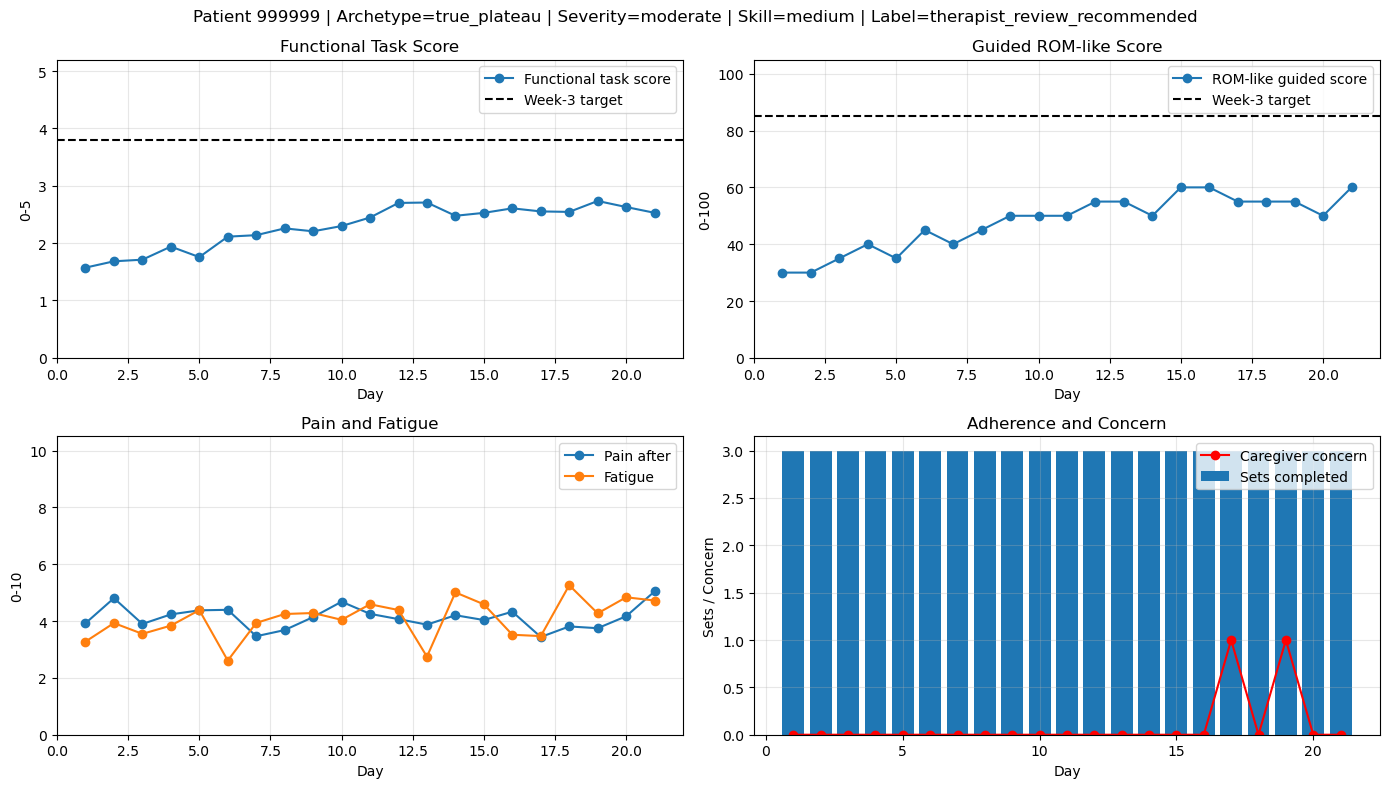

IndexError: single positional indexer is out-of-bounds

In [21]:
def create_james_like_case(patient_id=999999):
    """
    Add a deterministic James-like patient to profiles_df/daily_df/features.
    """

    profile = {
        "patient_id": patient_id,
        "age": 67,
        "severity": "moderate",
        "caregiver_skill": "medium",
        "caregiver_burden": "medium",
        "archetype": "true_plateau",

        "baseline_function": 1.5,
        "baseline_rom_score": 30.0,
        "pain_base": 3.0,

        "target_function_wk3": 3.8,
        "target_rom_wk3": 85.0,

        "measurement_noise": 5.0,
        "measurement_bias": 0.0,
        "rounding_increment": 5,

        "base_adherence_probability": 0.95,
        "logging_reliability": 0.98
    }

    records = []

    # Function improves some.
    function = np.concatenate([
        np.linspace(1.5, 2.6, 12),
        np.ones(9) * 2.6
    ])

    # ROM plateaus well below target.
    rom = np.concatenate([
        np.linspace(30, 55, 12),
        np.ones(9) * 55
    ])

    for d in range(DAYS):
        day = d + 1
        records.append({
            "patient_id": patient_id,
            "day": day,
            "log_entered": 1,
            "therapy_completed": 1,
            "sets_completed": 3,
            "pain_before": 3.0 + np.random.normal(0, 0.4),
            "pain_after": 4.0 + np.random.normal(0, 0.4),
            "fatigue": 4.0 + np.random.normal(0, 0.6),
            "assistance_required": 1,
            "caregiver_concern": 0 if d < 14 else int(np.random.rand() < 0.25),
            "functional_task_score": clamp(function[d] + np.random.normal(0, 0.1), 0, 5),
            "rom_score": clamp(round_to_increment(rom[d] + np.random.normal(0, 3), 5), 0, 100),
            "recommended_sets": 3
        })

    label = 1

    return profile, records, label

james_profile, james_records, james_label = create_james_like_case()

# Append to copies for demonstration.
profiles_df_j = pd.concat([profiles_df, pd.DataFrame([james_profile])], ignore_index=True)
daily_df_j = pd.concat([daily_df, pd.DataFrame(james_records)], ignore_index=True)
labels_df_j = pd.concat([
    labels_df,
    pd.DataFrame([{"patient_id": james_profile["patient_id"], "label": james_label}])
], ignore_index=True)

# Temporarily swap globals to use plotting functions.
old_profiles_df = profiles_df
old_daily_df = daily_df
old_labels_df = labels_df

profiles_df = profiles_df_j
daily_df = daily_df_j
labels_df = labels_df_j

james_features = make_features_for_patient(james_profile["patient_id"])
print(json.dumps({k: v for k, v in james_features.items() if k not in ["patient_id"]}, indent=2))

plot_patient_daily(james_profile["patient_id"])
caregiver_visualization(james_profile["patient_id"])

# Restore globals.
profiles_df = old_profiles_df
daily_df = old_daily_df
labels_df = old_labels_df

In [ ]:
z = intercept + sum(coef_i * ((x_i - mean_i) / scale_i))
probability = 1 / (1 + exp(-z))

In [ ]:
logistic_artifact = {
    "model_type": "logistic_regression",
    "model_version": "synthetic_realistic_v0.1",
    "feature_order": feature_cols,
    "scaler": {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    },
    "intercept": float(log_reg.intercept_[0]),
    "coefficients": log_reg.coef_[0].tolist(),
    "decision_threshold": SELECTED_THRESHOLD,
    "labels": LABELS,
    "input_notes": {
        "features": "Features are computed from 21 days of caregiver logs and care plan targets.",
        "normalization": "Each feature must be standardized with z = (x - mean) / scale before applying coefficients.",
        "output": "Probability that therapist review is recommended.",
        "safety": "Use as decision support only. Caregiver consent required before escalation."
    }
}

logistic_path = os.path.join(OUTPUT_DIR, "logistic_regression_mobile.json")

with open(logistic_path, "w") as f:
    json.dump(logistic_artifact, f, indent=2)

print("Saved:", logistic_path)

In [ ]:
pseudocode = f"""
// ACCESS-DP trajectory review score
// Model: logistic regression
// Version: synthetic_realistic_v0.1

// 1. Compute the features in this exact order:
{json.dumps(feature_cols, indent=2)}

// 2. Normalize:
for i in 0..<numFeatures {{
    x_scaled[i] = (x[i] - mean[i]) / scale[i]
}}

// 3. Logistic regression:
z = intercept
for i in 0..<numFeatures {{
    z += coefficients[i] * x_scaled[i]
}}

probability = 1.0 / (1.0 + exp(-z))

// 4. Decision:
if probability >= {SELECTED_THRESHOLD:.3f} {{
    showProgressGapVisualization()
    recommendTherapistReview()
}} else {{
    continueMonitoring()
}}

// 5. Human-in-the-loop:
if caregiverConfirmsEscalation && consentValid {{
    assembleProviderSummary()
    encryptAndQueueForSync()
}}
"""

pseudo_path = os.path.join(OUTPUT_DIR, "mobile_pseudocode.txt")
with open(pseudo_path, "w") as f:
    f.write(pseudocode)

print(pseudocode)

In [ ]:
profiles_path = os.path.join(OUTPUT_DIR, "synthetic_profiles.csv")
daily_path = os.path.join(OUTPUT_DIR, "synthetic_daily_logs.csv")
features_path = os.path.join(OUTPUT_DIR, "synthetic_features.csv")
labels_path = os.path.join(OUTPUT_DIR, "synthetic_labels.csv")

profiles_df.to_csv(profiles_path, index=False)
daily_df.to_csv(daily_path, index=False)
features_df.to_csv(features_path, index=False)
labels_df.to_csv(labels_path, index=False)

print("Saved:")
print(profiles_path)
print(daily_path)
print(features_path)
print(labels_path)

In [ ]:
summary = {
    "n_patients": N_PATIENTS,
    "days": DAYS,
    "label_distribution": labels_df["label"].value_counts(normalize=True).to_dict(),
    "features_used": feature_cols,
    "model_comparison": comparison.to_dict(orient="records"),
    "selected_model_recommendation": "clinical_rules_plus_logistic_regression",
    "selected_threshold": SELECTED_THRESHOLD,
    "artifacts": {
        "profiles": profiles_path,
        "daily_logs": daily_path,
        "features": features_path,
        "labels": labels_path,
        "logistic_mobile_json": logistic_path,
        "feature_columns": os.path.join(OUTPUT_DIR, "feature_columns.json"),
        "decision_tree_rules": os.path.join(OUTPUT_DIR, "decision_tree_rules.txt"),
        "model_comparison": os.path.join(OUTPUT_DIR, "model_comparison.csv"),
        "mobile_pseudocode": pseudo_path
    },
    "important_warning": (
        "Synthetic data is for engineering validation only. "
        "Clinical validation requires real therapist-reviewed patient trajectories."
    )
}

summary_path = os.path.join(OUTPUT_DIR, "summary_report.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))